In [1]:
!pip install yfinance ta scikit-learn xgboost joblib -q

import yfinance as yf
import pandas as pd
import numpy as np
import ta
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
import joblib
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

  Preparing metadata (setup.py) ... done


In [3]:
def build_feature_dataframe(ticker: str, period: str = "2y") -> pd.DataFrame:
    """
    Fetches OHLCV data and computes all technical indicators.
    Returns a clean dataframe ready for ML feature engineering.
    """
    # fetch
    t = yf.Ticker(ticker)
    df = t.history(period=period)
    df = df.drop(columns=['Dividends', 'Stock Splits'])
    df.index = df.index.tz_localize(None)
    df = df.ffill()
    
    # indicators
    df['RSI'] = ta.momentum.RSIIndicator(close=df['Close'], window=14).rsi()
    
    macd = ta.trend.MACD(close=df['Close'], window_slow=26, window_fast=12, window_sign=9)
    df['MACD'] = macd.macd()
    df['MACD_signal'] = macd.macd_signal()
    df['MACD_histogram'] = macd.macd_diff()
    
    bb = ta.volatility.BollingerBands(close=df['Close'], window=20, window_dev=2)
    df['BB_upper'] = bb.bollinger_hband()
    df['BB_mid'] = bb.bollinger_mavg()
    df['BB_lower'] = bb.bollinger_lband()
    df['BB_width'] = bb.bollinger_wband()
    
    df['SMA_50'] = ta.trend.SMAIndicator(close=df['Close'], window=50).sma_indicator()
    df['SMA_200'] = ta.trend.SMAIndicator(close=df['Close'], window=200).sma_indicator()
    df['EMA_12'] = ta.trend.EMAIndicator(close=df['Close'], window=12).ema_indicator()
    df['EMA_26'] = ta.trend.EMAIndicator(close=df['Close'], window=26).ema_indicator()
    
    # drop NaN rows — only keep rows where all indicators are computed
    df = df.dropna()
    
    return df

# test
df = build_feature_dataframe("RELIANCE.NS")
print(df.shape)
print(df.columns.tolist())

(297, 17)
['Open', 'High', 'Low', 'Close', 'Volume', 'RSI', 'MACD', 'MACD_signal', 'MACD_histogram', 'BB_upper', 'BB_mid', 'BB_lower', 'BB_width', 'SMA_50', 'SMA_200', 'EMA_12', 'EMA_26']


In [4]:
# CREATE TARGET VARIABLE
# For each day, look 5 trading days into the future
# Calculate % price change over those 5 days
# Label it UP / DOWN / NEUTRAL

FUTURE_DAYS = 5
THRESHOLD = 0.02  # 2%

# shift(-5) means "the Close price 5 days from now"
df['Future_Close'] = df['Close'].shift(-FUTURE_DAYS)
df['Future_Return'] = (df['Future_Close'] - df['Close']) / df['Close']

def label(ret):
    if ret > THRESHOLD:
        return 'UP'
    elif ret < -THRESHOLD:
        return 'DOWN'
    else:
        return 'NEUTRAL'

df['Target'] = df['Future_Return'].apply(label)

# drop the last 5 rows — they have no future data
df = df.dropna(subset=['Future_Close'])

# check class distribution
print("Target distribution:")
print(df['Target'].value_counts())
print(f"\nTotal rows: {len(df)}")
print(f"\nSample — last 10 rows:")
print(df[['Close', 'Future_Close', 'Future_Return', 'Target']].tail(10))

Target distribution:
Target
NEUTRAL    157
UP          71
DOWN        64
Name: count, dtype: int64

Total rows: 292

Sample — last 10 rows:
                  Close  Future_Close  Future_Return   Target
Date                                                         
2026-05-05  1463.599976   1364.000000      -0.068051     DOWN
2026-05-06  1437.900024   1358.800049      -0.055011     DOWN
2026-05-07  1436.199951   1361.800049      -0.051803     DOWN
2026-05-08  1435.199951   1336.400024      -0.068841     DOWN
2026-05-11  1388.199951   1335.900024      -0.037675     DOWN
2026-05-12  1364.000000   1322.699951      -0.030279     DOWN
2026-05-13  1358.800049   1359.699951       0.000662  NEUTRAL
2026-05-14  1361.800049   1349.599976      -0.008959  NEUTRAL
2026-05-15  1336.400024   1354.500000       0.013544  NEUTRAL
2026-05-18  1335.900024   1354.500000       0.013923  NEUTRAL


In [5]:
# FEATURE ENGINEERING
# Create derived features that capture momentum and relative position

# 1. Price position relative to moving averages
# "How far is price from its SMA?" is more useful than raw price
df['Price_vs_SMA50'] = (df['Close'] - df['SMA_50']) / df['SMA_50']
df['Price_vs_SMA200'] = (df['Close'] - df['SMA_200']) / df['SMA_200']
df['Price_vs_BB_mid'] = (df['Close'] - df['BB_mid']) / df['BB_mid']

# 2. Price position within Bollinger Bands
# 0 = at lower band, 1 = at upper band, 0.5 = at middle
df['BB_position'] = (df['Close'] - df['BB_lower']) / (df['BB_upper'] - df['BB_lower'])

# 3. Momentum — how much has price moved recently
df['Return_1d'] = df['Close'].pct_change(1)   # yesterday's return
df['Return_5d'] = df['Close'].pct_change(5)   # last 5 days return
df['Return_10d'] = df['Close'].pct_change(10) # last 10 days return

# 4. RSI momentum — is RSI rising or falling?
df['RSI_change'] = df['RSI'].diff(3)  # RSI change over last 3 days

# 5. MACD momentum — is histogram growing or shrinking?
df['MACD_hist_change'] = df['MACD_histogram'].diff(3)

# 6. Volume momentum — is volume increasing?
df['Volume_SMA20'] = df['Volume'].rolling(20).mean()
df['Volume_ratio'] = df['Volume'] / df['Volume_SMA20']  # >1 = above average volume

# drop any NaN created by these new features
df = df.dropna()

print(f"Shape after feature engineering: {df.shape}")
print(f"\nNew features added:")
new_features = ['Price_vs_SMA50', 'Price_vs_SMA200', 'Price_vs_BB_mid', 
                'BB_position', 'Return_1d', 'Return_5d', 'Return_10d',
                'RSI_change', 'MACD_hist_change', 'Volume_ratio']
print(df[new_features].tail(5).round(4))

Shape after feature engineering: (273, 31)

New features added:
            Price_vs_SMA50  Price_vs_SMA200  Price_vs_BB_mid  BB_position  \
Date                                                                        
2026-05-12         -0.0133          -0.0475          -0.0198       0.3391   
2026-05-13         -0.0165          -0.0509          -0.0241       0.3013   
2026-05-14         -0.0137          -0.0487          -0.0226       0.3096   
2026-05-15         -0.0313          -0.0662          -0.0398       0.1757   
2026-05-18         -0.0314          -0.0663          -0.0392       0.1903   

            Return_1d  Return_5d  Return_10d  RSI_change  MACD_hist_change  \
Date                                                                         
2026-05-12    -0.0174    -0.0681     -0.0179    -15.6730          -11.8212   
2026-05-13    -0.0038    -0.0550     -0.0467    -16.3267          -13.1920   
2026-05-14     0.0022    -0.0518     -0.0482     -4.6565          -10.1634   
2026-0

In [6]:
# DEFINE FEATURES AND TARGET
FEATURES = [
    'RSI', 'MACD', 'MACD_signal', 'MACD_histogram',
    'BB_width', 'BB_position',
    'SMA_50', 'SMA_200', 'EMA_12', 'EMA_26',
    'Price_vs_SMA50', 'Price_vs_SMA200', 'Price_vs_BB_mid',
    'Return_1d', 'Return_5d', 'Return_10d',
    'RSI_change', 'MACD_hist_change', 'Volume_ratio'
]

X = df[FEATURES]
y = df['Target']

# TEMPORAL SPLIT — critical, never use random split for financial data
# Reason: if you randomly split, your training data contains future dates
# and your test data contains past dates — model has "seen the future"
# This inflates accuracy artificially — called data leakage
# Correct approach: first 80% of dates = train, last 20% = test, strictly in order

split_idx = int(len(df) * 0.8)
split_date = df.index[split_idx]

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]
y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

print(f"Split date: {split_date.date()}")
print(f"Training: {len(X_train)} rows ({X_train.index[0].date()} to {X_train.index[-1].date()})")
print(f"Testing:  {len(X_test)} rows ({X_test.index[0].date()} to {X_test.index[-1].date()})")
print(f"\nTrain class distribution:\n{y_train.value_counts()}")
print(f"\nTest class distribution:\n{y_test.value_counts()}")

Split date: 2026-02-24
Training: 218 rows (2025-04-09 to 2026-02-23)
Testing:  55 rows (2026-02-24 to 2026-05-18)

Train class distribution:
Target
NEUTRAL    127
UP          51
DOWN        40
Name: count, dtype: int64

Test class distribution:
Target
NEUTRAL    25
DOWN       17
UP         13
Name: count, dtype: int64


CLASSIFICATION REPORT
              precision    recall  f1-score   support

        DOWN       1.00      0.18      0.30        17
     NEUTRAL       0.50      0.40      0.44        25
          UP       0.25      0.62      0.36        13

    accuracy                           0.38        55
   macro avg       0.58      0.40      0.37        55
weighted avg       0.60      0.38      0.38        55

CONFUSION MATRIX


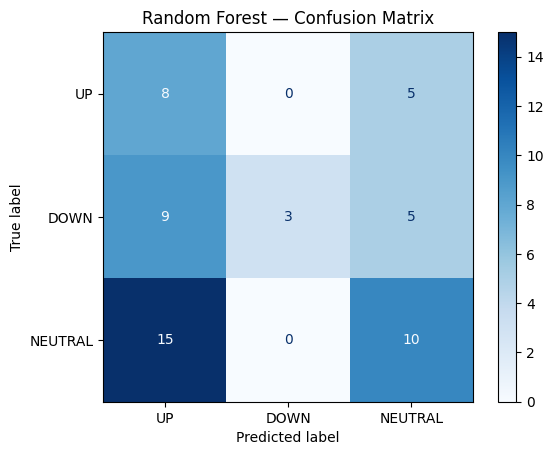

In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# TRAIN RANDOM FOREST
rf_model = RandomForestClassifier(
    n_estimators=200,      # 200 trees — more trees = more stable, diminishing returns after 200
    max_depth=6,           # prevents overfitting — trees can't go too deep
    min_samples_leaf=5,    # each leaf needs at least 5 samples — prevents memorizing noise
    class_weight='balanced', # compensates for NEUTRAL dominating — treats all classes equally
    random_state=42        # reproducibility — same result every run
)

rf_model.fit(X_train, y_train)

# EVALUATE
y_pred = rf_model.predict(X_test)

print("=" * 50)
print("CLASSIFICATION REPORT")
print("=" * 50)
print(classification_report(y_test, y_pred))

print("=" * 50)
print("CONFUSION MATRIX")
print("=" * 50)
cm = confusion_matrix(y_test, y_pred, labels=['UP', 'DOWN', 'NEUTRAL'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['UP', 'DOWN', 'NEUTRAL'])
disp.plot(cmap='Blues')
plt.title('Random Forest — Confusion Matrix')
plt.show()

In [8]:
# FIX 1: Get more data — use 5 years instead of 2
df5 = build_feature_dataframe("RELIANCE.NS", period="5y")

# add all the same features
df5['Price_vs_SMA50'] = (df5['Close'] - df5['SMA_50']) / df5['SMA_50']
df5['Price_vs_SMA200'] = (df5['Close'] - df5['SMA_200']) / df5['SMA_200']
df5['Price_vs_BB_mid'] = (df5['Close'] - df5['BB_mid']) / df5['BB_mid']
df5['BB_position'] = (df5['Close'] - df5['BB_lower']) / (df5['BB_upper'] - df5['BB_lower'])
df5['Return_1d'] = df5['Close'].pct_change(1)
df5['Return_5d'] = df5['Close'].pct_change(5)
df5['Return_10d'] = df5['Close'].pct_change(10)
df5['RSI_change'] = df5['RSI'].diff(3)
df5['MACD_hist_change'] = df5['MACD_histogram'].diff(3)
df5['Volume_SMA20'] = df5['Volume'].rolling(20).mean()
df5['Volume_ratio'] = df5['Volume'] / df5['Volume_SMA20']

# create target
df5['Future_Close'] = df5['Close'].shift(-5)
df5['Future_Return'] = (df5['Future_Close'] - df5['Close']) / df5['Close']
df5['Target'] = df5['Future_Return'].apply(label)
df5 = df5.dropna()

print(f"5-year dataset shape: {df5.shape}")
print(f"Target distribution:\n{df5['Target'].value_counts()}")

5-year dataset shape: (1015, 31)
Target distribution:
Target
NEUTRAL    528
UP         253
DOWN       234
Name: count, dtype: int64


Training: 812 rows (2022-04-07 to 2025-07-21)
Testing:  203 rows (2025-07-22 to 2026-05-18)

CLASSIFICATION REPORT — 5 year data
              precision    recall  f1-score   support

        DOWN       0.24      0.65      0.35        43
     NEUTRAL       0.53      0.27      0.36       119
          UP       0.25      0.15      0.18        41

    accuracy                           0.33       203
   macro avg       0.34      0.36      0.30       203
weighted avg       0.41      0.33      0.32       203



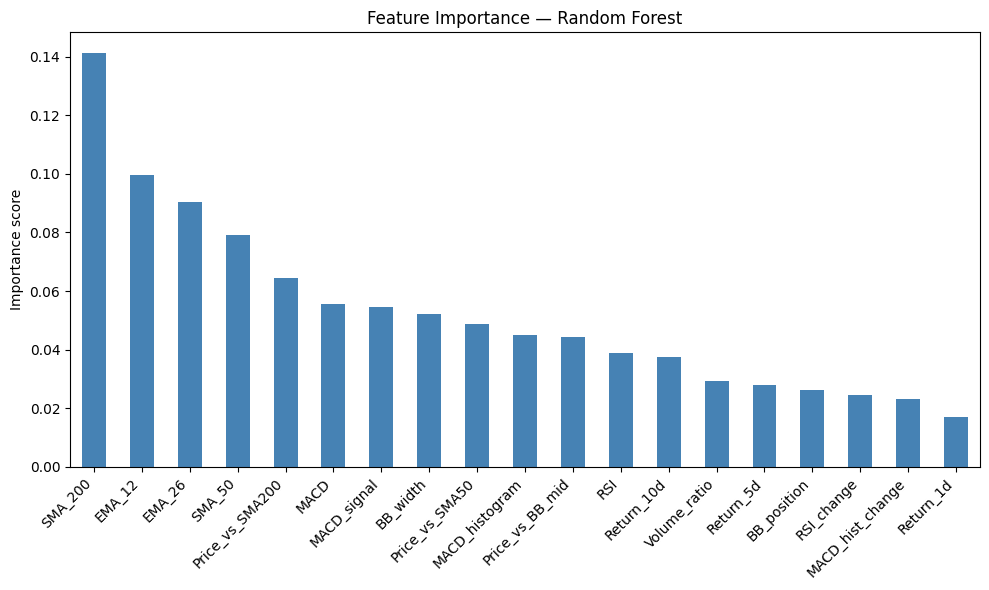


Top 5 most important features:
SMA_200            0.141253
EMA_12             0.099551
EMA_26             0.090363
SMA_50             0.078989
Price_vs_SMA200    0.064370
dtype: float64


In [9]:
# retrain with 5 year data
X5 = df5[FEATURES]
y5 = df5['Target']

# temporal split — same logic, strictly in order
split_idx5 = int(len(df5) * 0.8)

X5_train = X5.iloc[:split_idx5]
X5_test = X5.iloc[split_idx5:]
y5_train = y5.iloc[:split_idx5]
y5_test = y5.iloc[split_idx5:]

print(f"Training: {len(X5_train)} rows ({X5_train.index[0].date()} to {X5_train.index[-1].date()})")
print(f"Testing:  {len(X5_test)} rows ({X5_test.index[0].date()} to {X5_test.index[-1].date()})")

# train
rf_model5 = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42
)

rf_model5.fit(X5_train, y5_train)
y5_pred = rf_model5.predict(X5_test)

print("\n" + "=" * 50)
print("CLASSIFICATION REPORT — 5 year data")
print("=" * 50)
print(classification_report(y5_test, y5_pred))

# feature importance — what did the model find most useful?
importances = pd.Series(rf_model5.feature_importances_, index=FEATURES)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
importances.plot(kind='bar', color='steelblue')
plt.title('Feature Importance — Random Forest')
plt.ylabel('Importance score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nTop 5 most important features:")
print(importances.head())

In [10]:
# SIMPLIFIED: binary classification — UP vs DOWN only
# drop NEUTRAL rows — only keep decisive moves
df_binary = df5[df5['Target'] != 'NEUTRAL'].copy()
df_binary['Target_binary'] = (df_binary['Target'] == 'UP').astype(int)
# 1 = UP, 0 = DOWN

print(f"Binary dataset shape: {df_binary.shape}")
print(f"Class distribution:\n{df_binary['Target_binary'].value_counts()}")
print(f"UP: {(df_binary['Target_binary']==1).sum()}, DOWN: {(df_binary['Target_binary']==0).sum()}")

Binary dataset shape: (487, 32)
Class distribution:
Target_binary
1    253
0    234
Name: count, dtype: int64
UP: 253, DOWN: 234


In [11]:
# use only last 2 years of data for binary model
cutoff = df_binary.index[-1] - pd.DateOffset(years=2)
df_recent = df_binary[df_binary.index >= cutoff]

print(f"\nRecent 2-year binary dataset: {df_recent.shape}")
print(f"Date range: {df_recent.index[0].date()} to {df_recent.index[-1].date()}")


Recent 2-year binary dataset: (239, 32)
Date range: 2024-05-13 to 2026-05-12


Training: 191 rows (2024-05-13 to 2026-01-05)
Testing:  48 rows (2026-01-06 to 2026-05-12)

BINARY CLASSIFICATION REPORT
              precision    recall  f1-score   support

        DOWN       0.62      1.00      0.77        30
          UP       0.00      0.00      0.00        18

    accuracy                           0.62        48
   macro avg       0.31      0.50      0.38        48
weighted avg       0.39      0.62      0.48        48



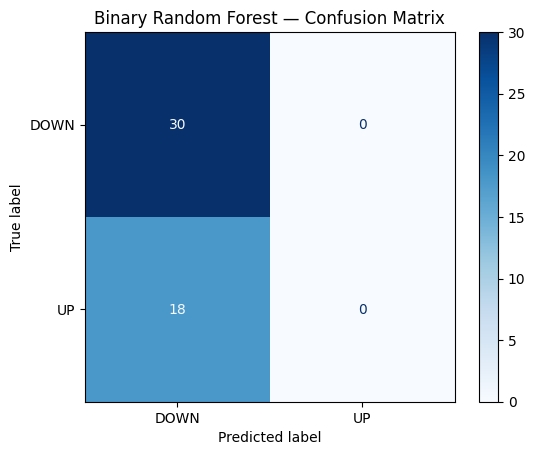

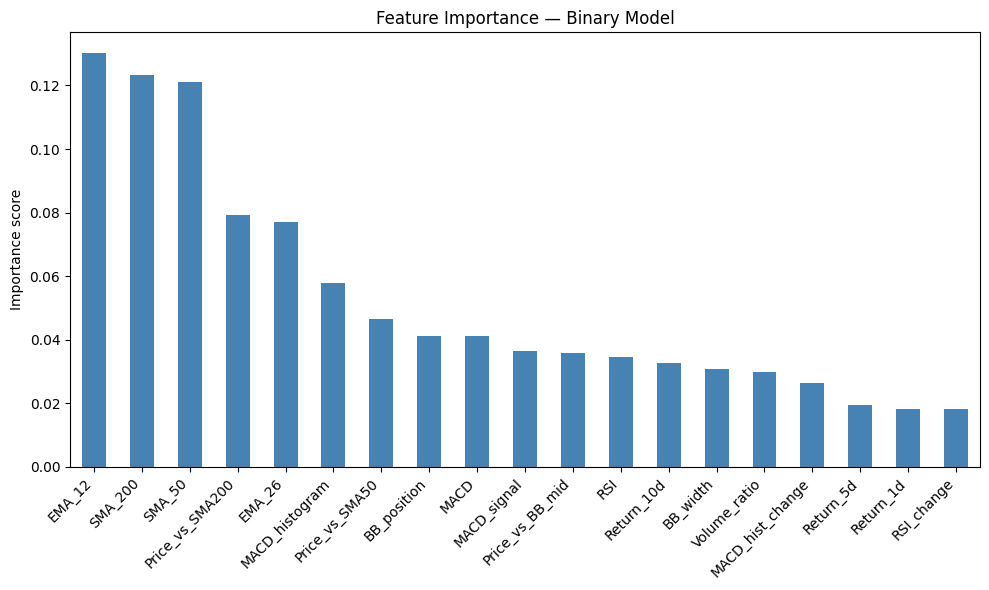


Top 5 features:
EMA_12             0.130207
SMA_200            0.123366
SMA_50             0.121063
Price_vs_SMA200    0.079326
EMA_26             0.077020
dtype: float64


In [12]:
# BINARY MODEL — UP vs DOWN only, recent 2 years
X_bin = df_recent[FEATURES]
y_bin = df_recent['Target_binary']

# temporal split
split_idx_bin = int(len(df_recent) * 0.8)

X_bin_train = X_bin.iloc[:split_idx_bin]
X_bin_test = X_bin.iloc[split_idx_bin:]
y_bin_train = y_bin.iloc[:split_idx_bin]
y_bin_test = y_bin.iloc[split_idx_bin:]

print(f"Training: {len(X_bin_train)} rows ({X_bin_train.index[0].date()} to {X_bin_train.index[-1].date()})")
print(f"Testing:  {len(X_bin_test)} rows ({X_bin_test.index[0].date()} to {X_bin_test.index[-1].date()})")

# train
rf_binary = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,          # slightly shallower — less overfitting on smaller dataset
    min_samples_leaf=4,
    class_weight='balanced',
    random_state=42
)

rf_binary.fit(X_bin_train, y_bin_train)
y_bin_pred = rf_binary.predict(X_bin_test)
y_bin_proba = rf_binary.predict_proba(X_bin_test)  # confidence scores

print("\n" + "=" * 50)
print("BINARY CLASSIFICATION REPORT")
print("=" * 50)
print(classification_report(y_bin_test, y_bin_pred, target_names=['DOWN', 'UP']))

# confusion matrix
cm = confusion_matrix(y_bin_test, y_bin_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['DOWN', 'UP'])
disp.plot(cmap='Blues')
plt.title('Binary Random Forest — Confusion Matrix')
plt.show()

# feature importance
importances = pd.Series(rf_binary.feature_importances_, index=FEATURES)
importances = importances.sort_values(ascending=False)
plt.figure(figsize=(10, 6))
importances.plot(kind='bar', color='steelblue')
plt.title('Feature Importance — Binary Model')
plt.ylabel('Importance score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nTop 5 features:")
print(importances.head())

In [13]:
from xgboost import XGBClassifier
from sklearn.model_selection import TimeSeriesSplit, cross_val_score

# XGBoost — better than Random Forest on small tabular datasets
# handles class imbalance natively with scale_pos_weight

n_down = (y_bin_train == 0).sum()
n_up = (y_bin_train == 1).sum()
scale = n_down / n_up  # weight UP examples more since they're fewer

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=3,           # shallow — critical for small datasets
    learning_rate=0.05,    # slow learning = less overfitting
    subsample=0.8,         # use 80% of rows per tree — reduces overfitting
    colsample_bytree=0.8,  # use 80% of features per tree
    scale_pos_weight=scale,# compensates for class imbalance
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)

# TimeSeriesSplit — cross validation that respects time order
# splits data into 5 folds, always training on past, testing on future
tscv = TimeSeriesSplit(n_splits=5)

cv_scores = cross_val_score(
    xgb_model, X_bin, y_bin,
    cv=tscv,
    scoring='f1_macro'
)

print("Time Series Cross Validation F1 scores:")
for i, score in enumerate(cv_scores):
    print(f"  Fold {i+1}: {score:.3f}")
print(f"  Mean: {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})")

# train final model on train split, evaluate on test
xgb_model.fit(X_bin_train, y_bin_train)
y_xgb_pred = xgb_model.predict(X_bin_test)
y_xgb_proba = xgb_model.predict_proba(X_bin_test)

print("\n" + "="*50)
print("XGBoost CLASSIFICATION REPORT")
print("="*50)
print(classification_report(y_bin_test, y_xgb_pred, target_names=['DOWN', 'UP']))

Time Series Cross Validation F1 scores:
  Fold 1: 0.292
  Fold 2: 0.545
  Fold 3: 0.481
  Fold 4: 0.567
  Fold 5: 0.529
  Mean: 0.483 (+/- 0.099)

XGBoost CLASSIFICATION REPORT
              precision    recall  f1-score   support

        DOWN       0.62      1.00      0.77        30
          UP       0.00      0.00      0.00        18

    accuracy                           0.62        48
   macro avg       0.31      0.50      0.38        48
weighted avg       0.39      0.62      0.48        48



In [14]:
# THE REAL FIX — adjust threshold and prediction window
# Problem: 2% threshold over 5 days creates too many DOWN labels
# in a bearish period, making UP nearly unpredictable
# Solution: use 1% threshold and 3-day window — more balanced labels

def create_target(df, future_days=3, threshold=0.01):
    df = df.copy()
    df['Future_Close'] = df['Close'].shift(-future_days)
    df['Future_Return'] = (df['Future_Close'] - df['Close']) / df['Close']
    
    def label(ret):
        if ret > threshold:
            return 1  # UP
        else:
            return 0  # DOWN
    
    df['Target_binary'] = df['Future_Return'].apply(label)
    df = df.dropna(subset=['Future_Close'])
    return df

# rebuild on full 5y data with new threshold
df5_new = build_feature_dataframe("RELIANCE.NS", period="5y")

# add features
df5_new['Price_vs_SMA50'] = (df5_new['Close'] - df5_new['SMA_50']) / df5_new['SMA_50']
df5_new['Price_vs_SMA200'] = (df5_new['Close'] - df5_new['SMA_200']) / df5_new['SMA_200']
df5_new['Price_vs_BB_mid'] = (df5_new['Close'] - df5_new['BB_mid']) / df5_new['BB_mid']
df5_new['BB_position'] = (df5_new['Close'] - df5_new['BB_lower']) / (df5_new['BB_upper'] - df5_new['BB_lower'])
df5_new['Return_1d'] = df5_new['Close'].pct_change(1)
df5_new['Return_5d'] = df5_new['Close'].pct_change(5)
df5_new['Return_10d'] = df5_new['Close'].pct_change(10)
df5_new['RSI_change'] = df5_new['RSI'].diff(3)
df5_new['MACD_hist_change'] = df5_new['MACD_histogram'].diff(3)
df5_new['Volume_SMA20'] = df5_new['Volume'].rolling(20).mean()
df5_new['Volume_ratio'] = df5_new['Volume'] / df5_new['Volume_SMA20']
df5_new = df5_new.dropna()

# apply new target
df5_new = create_target(df5_new, future_days=3, threshold=0.01)

print(f"Shape: {df5_new.shape}")
print(f"Class distribution:\n{df5_new['Target_binary'].value_counts()}")
print(f"Balance ratio: {df5_new['Target_binary'].mean():.2f} (0.5 = perfect)")

Shape: (1017, 31)
Class distribution:
Target_binary
0    687
1    330
Name: count, dtype: int64
Balance ratio: 0.32 (0.5 = perfect)


In [15]:
from sklearn.utils import resample

# HANDLE IMBALANCE PROPERLY — undersample majority class
# keep all UP rows, randomly sample equal number of DOWN rows
# do this only on training data, never on test data

X5_new = df5_new[FEATURES]
y5_new = df5_new['Target_binary']

# temporal split first
split_idx = int(len(df5_new) * 0.8)
X_tr = X5_new.iloc[:split_idx]
X_te = X5_new.iloc[split_idx:]
y_tr = y5_new.iloc[:split_idx]
y_te = y5_new.iloc[split_idx:]

print(f"Train: {len(X_tr)} rows | Test: {len(X_te)} rows")
print(f"Train distribution:\n{y_tr.value_counts()}")
print(f"Test distribution:\n{y_te.value_counts()}")

# undersample training data only
train_df = pd.concat([X_tr, y_tr], axis=1)
down_rows = train_df[train_df['Target_binary'] == 0]
up_rows = train_df[train_df['Target_binary'] == 1]

# downsample DOWN to match UP count
down_downsampled = resample(down_rows, 
                            n_samples=len(up_rows), 
                            random_state=42)

train_balanced = pd.concat([up_rows, down_downsampled])
train_balanced = train_balanced.sample(frac=1, random_state=42)  # shuffle

X_tr_bal = train_balanced[FEATURES]
y_tr_bal = train_balanced['Target_binary']

print(f"\nBalanced training set: {len(X_tr_bal)} rows")
print(f"Distribution:\n{y_tr_bal.value_counts()}")

Train: 813 rows | Test: 204 rows
Train distribution:
Target_binary
0    550
1    263
Name: count, dtype: int64
Test distribution:
Target_binary
0    137
1     67
Name: count, dtype: int64

Balanced training set: 526 rows
Distribution:
Target_binary
0    263
1    263
Name: count, dtype: int64


FINAL MODEL — CLASSIFICATION REPORT
              precision    recall  f1-score   support

        DOWN       0.63      0.37      0.47       137
          UP       0.30      0.55      0.39        67

    accuracy                           0.43       204
   macro avg       0.47      0.46      0.43       204
weighted avg       0.52      0.43      0.44       204



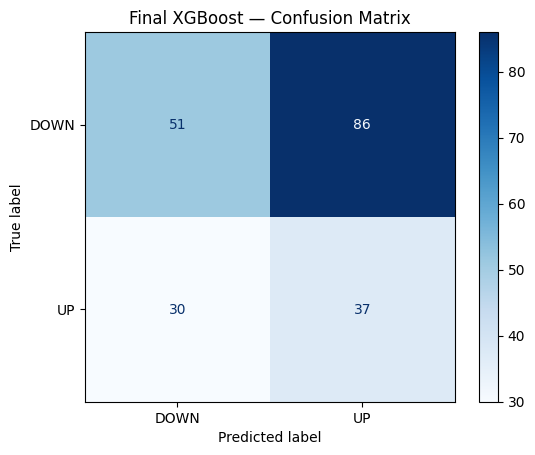

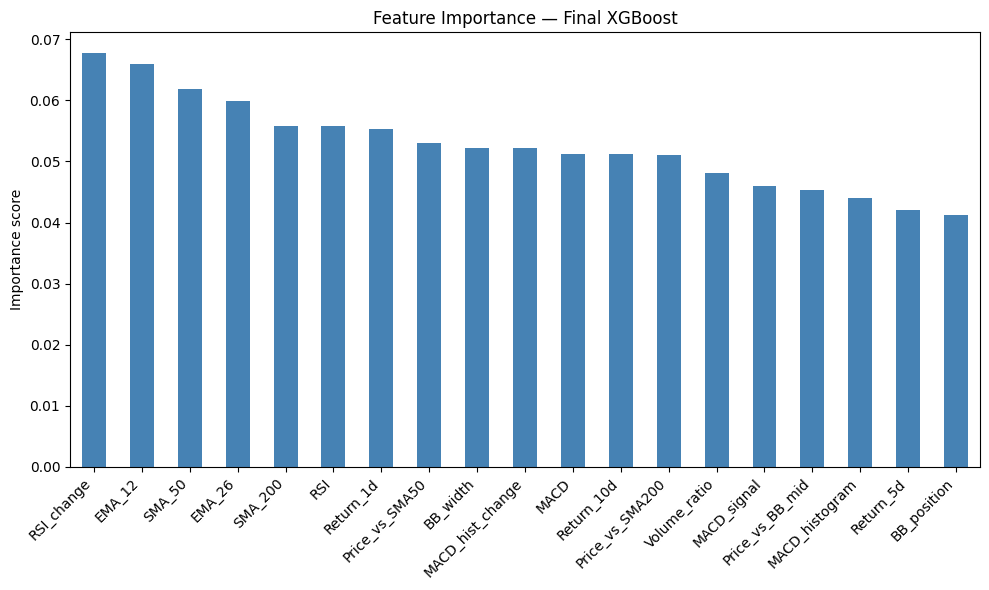

Top 5 features:
RSI_change    0.067752
EMA_12        0.065967
SMA_50        0.061929
EMA_26        0.059951
SMA_200       0.055764
dtype: float32


In [16]:
# FINAL MODEL — XGBoost on balanced training data
xgb_final = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)

xgb_final.fit(X_tr_bal, y_tr_bal)
y_final_pred = xgb_final.predict(X_te)
y_final_proba = xgb_final.predict_proba(X_te)

print("="*50)
print("FINAL MODEL — CLASSIFICATION REPORT")
print("="*50)
print(classification_report(y_te, y_final_pred, target_names=['DOWN', 'UP']))

# confusion matrix
cm = confusion_matrix(y_te, y_final_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['DOWN', 'UP'])
disp.plot(cmap='Blues')
plt.title('Final XGBoost — Confusion Matrix')
plt.show()

# feature importance
importances = pd.Series(xgb_final.feature_importances_, index=FEATURES)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
importances.plot(kind='bar', color='steelblue')
plt.title('Feature Importance — Final XGBoost')
plt.ylabel('Importance score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Top 5 features:")
print(importances.head())

In [17]:
def predict_signal(ticker: str) -> dict:
    """
    Given a ticker, returns UP/DOWN signal with confidence score.
    This is what the FastAPI /stock/{ticker}/signal endpoint will call.
    """
    # build features for this ticker
    df_pred = build_feature_dataframe(ticker, period="5y")
    
    # add all features
    df_pred['Price_vs_SMA50'] = (df_pred['Close'] - df_pred['SMA_50']) / df_pred['SMA_50']
    df_pred['Price_vs_SMA200'] = (df_pred['Close'] - df_pred['SMA_200']) / df_pred['SMA_200']
    df_pred['Price_vs_BB_mid'] = (df_pred['Close'] - df_pred['BB_mid']) / df_pred['BB_mid']
    df_pred['BB_position'] = (df_pred['Close'] - df_pred['BB_lower']) / (df_pred['BB_upper'] - df_pred['BB_lower'])
    df_pred['Return_1d'] = df_pred['Close'].pct_change(1)
    df_pred['Return_5d'] = df_pred['Close'].pct_change(5)
    df_pred['Return_10d'] = df_pred['Close'].pct_change(10)
    df_pred['RSI_change'] = df_pred['RSI'].diff(3)
    df_pred['MACD_hist_change'] = df_pred['MACD_histogram'].diff(3)
    df_pred['Volume_SMA20'] = df_pred['Volume'].rolling(20).mean()
    df_pred['Volume_ratio'] = df_pred['Volume'] / df_pred['Volume_SMA20']
    df_pred = df_pred.dropna()
    
    # get the latest row — today's features
    latest = df_pred[FEATURES].iloc[[-1]]
    
    # predict
    proba = xgb_final.predict_proba(latest)[0]
    pred = xgb_final.predict(latest)[0]
    
    signal = "UP" if pred == 1 else "DOWN"
    confidence = float(proba[pred])
    
    # feature importances for explainability
    top_features = importances.head(3).index.tolist()
    
    return {
        "ticker": ticker,
        "signal": signal,
        "confidence": round(confidence, 3),
        "top_features": top_features,
        "disclaimer": "ML signal only — not financial advice"
    }

# test it
result = predict_signal("RELIANCE.NS")
print(result)

result_tcs = predict_signal("TCS.NS")
print(result_tcs)

{'ticker': 'RELIANCE.NS', 'signal': 'UP', 'confidence': 0.562, 'top_features': ['RSI_change', 'EMA_12', 'SMA_50'], 'disclaimer': 'ML signal only — not financial advice'}
{'ticker': 'TCS.NS', 'signal': 'DOWN', 'confidence': 0.555, 'top_features': ['RSI_change', 'EMA_12', 'SMA_50'], 'disclaimer': 'ML signal only — not financial advice'}


In [18]:
import joblib
import os

# create ml folder if it doesn't exist
os.makedirs('ml', exist_ok=True)

# save the trained model
joblib.dump(xgb_final, 'ml/price_model.pkl')

# save the feature list — backend needs to know exact feature order
joblib.dump(FEATURES, 'ml/features.pkl')

# verify it saved and can be loaded back
loaded_model = joblib.load('ml/price_model.pkl')
loaded_features = joblib.load('ml/features.pkl')

# test loaded model gives same result
test_result = predict_signal("RELIANCE.NS")
print("Model saved and verified.")
print(f"Signal: {test_result['signal']}, Confidence: {test_result['confidence']}")
print(f"Features list saved: {len(loaded_features)} features")

Model saved and verified.
Signal: UP, Confidence: 0.562
Features list saved: 19 features


In [20]:
!pip install feedparser -q

from transformers import pipeline
import feedparser

print("Loading FinBERT...")
finbert = pipeline(
    "text-classification", 
    model="ProsusAI/finbert",
    return_all_scores=True
)
print("FinBERT loaded.")

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.5/81.5 kB 2.7 MB/s eta 0:00:00
Loading FinBERT...


config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

FinBERT loaded.


In [26]:
BLOCKED_SOURCES = ["facebook.com", "twitter.com", "instagram.com", "reddit.com"]

def fetch_headlines(company_name: str) -> list:
    try:
        query = company_name.replace(" ", "+")
        url = f"https://news.google.com/rss/search?q={query}&hl=en-IN&gl=IN&ceid=IN:en"
        feed = feedparser.parse(url)
        if not feed.entries:
            return []
        headlines = [
            {
                "title": entry.title,
                "published_at": entry.published,
                "source": entry.source.get("title", "Google News") if hasattr(entry, "source") else "Google News"
            }
            for entry in feed.entries[:15]
            if not any(
                blocked in (entry.source.get("title", "") if hasattr(entry, "source") else "").lower()
                for blocked in BLOCKED_SOURCES
            )
        ]
        return headlines
    except Exception as e:
        print(f"Error: {e}")
        return []

In [27]:
def analyze_sentiment(company_name: str) -> dict:
    """
    Fetches headlines for a company and runs FinBERT sentiment on each.
    Returns individual headline sentiments + 7-day aggregate score.
    """
    headlines = fetch_headlines(company_name)
    
    if not headlines:
        return {"error": "No headlines found", "headlines": [], "aggregate": None}
    
    results = []
    for h in headlines:
        # run FinBERT on headline title
        scores = finbert(h['title'])[0]  # returns list of {label, score} for all 3 classes
        
        # convert to dict for easy access
        score_dict = {s['label']: s['score'] for s in scores}
        
        # dominant sentiment = highest scoring label
        dominant = max(score_dict, key=score_dict.get)
        confidence = score_dict[dominant]
        
        results.append({
            "title": h['title'],
            "source": h['source'],
            "published_at": h['published_at'],
            "sentiment": dominant,        # positive / negative / neutral
            "confidence": round(confidence, 3),
            "scores": {k: round(v, 3) for k, v in score_dict.items()}
        })
    
    # aggregate score — convert to numeric for averaging
    # positive = +1, negative = -1, neutral = 0
    # weighted by confidence score
    sentiment_map = {"positive": 1, "negative": -1, "neutral": 0}
    aggregate = sum(
        sentiment_map[r['sentiment']] * r['confidence'] 
        for r in results
    ) / len(results)
    
    # overall label
    if aggregate > 0.1:
        overall = "BULLISH"
    elif aggregate < -0.1:
        overall = "BEARISH"
    else:
        overall = "NEUTRAL"
    
    return {
        "company": company_name,
        "headlines_analyzed": len(results),
        "aggregate_score": round(aggregate, 3),
        "overall_sentiment": overall,
        "headlines": results
    }

# test
result = analyze_sentiment("Reliance Industries")
print(f"Company: {result['company']}")
print(f"Headlines analyzed: {result['headlines_analyzed']}")
print(f"Aggregate score: {result['aggregate_score']}")
print(f"Overall sentiment: {result['overall_sentiment']}")
print(f"\nHeadline breakdown:")
for h in result['headlines']:
    print(f"  [{h['sentiment'].upper()} {h['confidence']}] {h['title'][:70]}...")

TypeError: string indices must be integers, not 'str'

In [28]:
# debug — see exact output structure from FinBERT
test_headline = "Reliance Industries reports record quarterly profit"
raw_output = finbert(test_headline)
print(type(raw_output))
print(raw_output)

<class 'list'>
[{'label': 'positive', 'score': 0.7533596158027649}]


In [29]:
def analyze_sentiment(company_name: str) -> dict:
    headlines = fetch_headlines(company_name)
    
    if not headlines:
        return {"error": "No headlines found", "headlines": [], "aggregate": None}
    
    results = []
    for h in headlines:
        # FinBERT returns list with single dict: [{'label': 'positive', 'score': 0.75}]
        output = finbert(h['title'])[0]  # get the single result dict
        
        dominant = output['label']       # 'positive', 'negative', or 'neutral'
        confidence = output['score']
        
        results.append({
            "title": h['title'],
            "source": h['source'],
            "published_at": h['published_at'],
            "sentiment": dominant,
            "confidence": round(confidence, 3)
        })
    
    # aggregate score
    sentiment_map = {"positive": 1, "negative": -1, "neutral": 0}
    aggregate = sum(
        sentiment_map[r['sentiment']] * r['confidence']
        for r in results
    ) / len(results)
    
    if aggregate > 0.1:
        overall = "BULLISH"
    elif aggregate < -0.1:
        overall = "BEARISH"
    else:
        overall = "NEUTRAL"
    
    return {
        "company": company_name,
        "headlines_analyzed": len(results),
        "aggregate_score": round(aggregate, 3),
        "overall_sentiment": overall,
        "headlines": results
    }

# test
result = analyze_sentiment("Reliance Industries")
print(f"Company: {result['company']}")
print(f"Headlines analyzed: {result['headlines_analyzed']}")
print(f"Aggregate score: {result['aggregate_score']}")
print(f"Overall sentiment: {result['overall_sentiment']}")
print(f"\nHeadline breakdown:")
for h in result['headlines']:
    print(f"  [{h['sentiment'].upper()} {h['confidence']}] {h['title'][:70]}...")

Company: Reliance Industries
Headlines analyzed: 14
Aggregate score: 0.358
Overall sentiment: BULLISH

Headline breakdown:
  [POSITIVE 0.88] Reliance Industries becomes first Indian company to surpass $120 bln r...
  [POSITIVE 0.75] Maharashtra signs ₹6.5 lakh crore nuclear push with NTPC, Reliance and...
  [POSITIVE 0.863] Market recap: 6 of top-10 most-valued firms add Rs 74,111 crore; Relia...
  [NEUTRAL 0.594] JioStar reduces pressure on The Walt Disney Company earnings as India ...
  [NEGATIVE 0.973] RIL shares fall over 2% post Q1 results; analysts say it missed estima...
  [NEUTRAL 0.488] Reliance bribery probe: Executive gets bail after company hands over d...
  [POSITIVE 0.67] Disney-Reliance Media Bet Begins Stabilising as JioStar Narrows Financ...
  [NEUTRAL 0.919] Reliance Industries Ltd is Rated Sell - Markets Mojo...
  [NEUTRAL 0.95] Buy, Sell Or Hold: DLF, Ireda, Reliance Industries, Inox India, Castro...
  [NEUTRAL 0.512] India may end refined copper import dependence t